# Cheemalavagu et al. (2024) verification

This notebook runs BioNetGen, independently integrates its 53-species/122-reaction mass-action network with SciPy, compares the curated IL-6 10 ng/mL trajectory with the authors’ supplied ensemble trajectory, and compares all six fitted cytokine conditions with the pooled Figure 2B data. Experimental sheets were baseline-shifted, clipped at zero, normalized within experiment to IL-6 10 ng/mL at 20 min, interpolated, and averaged as described in the STAR Methods and authors’ notebook.

In [1]:
from pathlib import Path
import os,re,shutil,subprocess,tempfile
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
HERE=Path.cwd(); MODEL=HERE/'jak_stat_signaling_cheemalavagu2024.bngl'; REF=HERE/'reference'
BNG=Path(os.environ['BNGPATH'])/'BNG2.pl'; assert BNG.is_file()
COLORS={'il6_1':'#f48fb1','il6_10':'#d32f2f','il10_1':'#26c6da','il10_10':'#1976d2','il6_1_il10_1':'#ba68c8','il6_10_il10_10':'#512da8'}
def run_bng(path,out):
 p=subprocess.run(['perl',str(BNG),'--outdir',str(out),str(path)],capture_output=True,text=True,env=os.environ)
 assert p.returncode == 0, p.stdout+'\n'+p.stderr
 return pd.read_csv(out/f'{path.stem}_ode.gdat',sep=r'\s+',comment='#',names=['time','Obs_pSTAT3','Obs_pSTAT1'])
with tempfile.TemporaryDirectory() as t:bng=run_bng(MODEL,Path(t))
bng.head()

,time,Obs_pSTAT3,Obs_pSTAT1
0,0.0,0.000000,0.000000
1,1.0,0.006675,0.000080
2,2.0,0.022504,0.000293
3,3.0,0.041548,0.000602
4,4.0,0.059687,0.000976


## Independent mass-action ODE integration

The `.net` parser below builds the stoichiometric matrix and propensities itself and uses SciPy BDF, independently of BioNetGen’s `run_network` integrator.

In [2]:
text=(REF/'jak_stat_signaling_cheemalavagu2024_ode.net').read_text()
def block(name):return text.split(f'begin {name}',1)[1].split(f'end {name}',1)[0]
params={}
for line in block('parameters').splitlines():
 f=line.split('#',1)[0].split()
 if len(f)>=3:params[f[1]]=float(f[2])
sp=[x.split('#',1)[0].split() for x in block('species').splitlines() if x.strip()]
y0=np.array([params.get(x[-1],float(x[-1]) if re.fullmatch(r'[-+0-9.eE]+',x[-1]) else np.nan) for x in sp]); n=len(y0)
rx=[]; cols=[]
for line in block('reactions').splitlines():
 f=line.split('#',1)[0].split()
 if not f:continue
 rea=[] if f[1]=='0' else [int(x)-1 for x in f[1].split(',')]; pro=[] if f[2]=='0' else [int(x)-1 for x in f[2].split(',')]
 v=np.zeros(n)
 for i in rea:v[i]-=1
 for i in pro:v[i]+=1
 rx.append((rea,eval(f[3],{'__builtins__':{}},params)));cols.append(v)
S=np.array(cols).T
def rhs(t,y):return S@np.array([k*np.prod(y[i]) if i else k for i,k in rx])
sol=solve_ivp(rhs,(0,90),y0,method='BDF',t_eval=np.arange(91),rtol=1e-10,atol=1e-12);assert sol.success
groups={}
for line in block('groups').splitlines():
 f=line.split();terms=[]
 if not f:continue
 for x in f[2].split(','):
  a,i=x.split('*') if '*' in x else ('1',x);terms.append((float(a),int(i)-1))
 groups[f[1]]=sum(a*sol.y[i] for a,i in terms)
ind=pd.DataFrame({'time':sol.t,**groups}); obs=['Obs_pSTAT3','Obs_pSTAT1']
err=np.abs(ind[obs].to_numpy()-bng[obs].to_numpy());scale=np.maximum(np.abs(bng[obs].to_numpy()),1e-10)
print('independent max abs',err.max(),'max scaled',np.max(err/scale))

independent max abs 1.5297066155439687e-08 max scaled 4.7073377970310805e-07


In [3]:
author=pd.read_csv(REF/'cheemalavagu2024_author_il6_10_ensemble1817.csv')
aerr=np.abs(author[obs].to_numpy()-bng[obs].to_numpy());ascale=np.maximum(np.abs(author[obs].to_numpy()),1e-10)
print('author trajectory max abs',aerr.max(),'max rel (t>0)',np.max(aerr[1:]/ascale[1:]))

author trajectory max abs 7.303184499998783e-06 max rel (t>0) 0.0005632452264339121


## Figure 2B pooled-data comparison

The paper assigns 15% of the mean as uncertainty. A 0.02 floor is used only for baseline or near-zero points to avoid division by zero and reflect plotted precision.

In [4]:
conds={'il6_1':(1,0),'il6_10':(10,0),'il10_1':(0,1),'il10_10':(0,10),'il6_1_il10_1':(1,1),'il6_10_il10_10':(10,10)}
src=MODEL.read_text();tr={}
with tempfile.TemporaryDirectory() as t:
 t=Path(t)
 for name,(l1,l2) in conds.items():
  s=re.sub(r'(?m)^  L1_0\s+[-+0-9.eE]+',f'  L1_0                         {l1}',src);s=re.sub(r'(?m)^  L2_0\s+[-+0-9.eE]+',f'  L2_0                         {l2}',s)
  p=t/f'{name}.bngl';p.write_text(s);tr[name]=run_bng(p,t)
reported=pd.read_csv(REF/'cheemalavagu2024_fig2b_pooled.csv');norm={o:tr['il6_10'].loc[20,o] for o in obs};rows=[]
for name,sim in tr.items():
 d=reported[reported.condition==name]
 for o,label in [('Obs_pSTAT3','pSTAT3'),('Obs_pSTAT1','pSTAT1')]:
  pred=np.interp(d.time,sim.time,sim[o])/norm[o]; rows += list(zip([name]*len(d),[o]*len(d),d.time,d[f'{label}_mean'],pred,d[f'{label}_fit_SD']))
cmp=pd.DataFrame(rows,columns=['condition','observable','time','data','model','SD']);cmp['z']=(cmp.model-cmp.data)/cmp.SD;cmp['rel']=np.abs(cmp.model-cmp.data)/np.maximum(cmp.data,.02)
chi2=float(np.sum(cmp.z**2));print('chi-square',chi2,'median rel',np.median(cmp.rel),'p90 rel',np.quantile(cmp.rel,.9))

chi-square 74.48228552711491 median rel 0.08780665086540312 p90 rel 0.30763181738647877


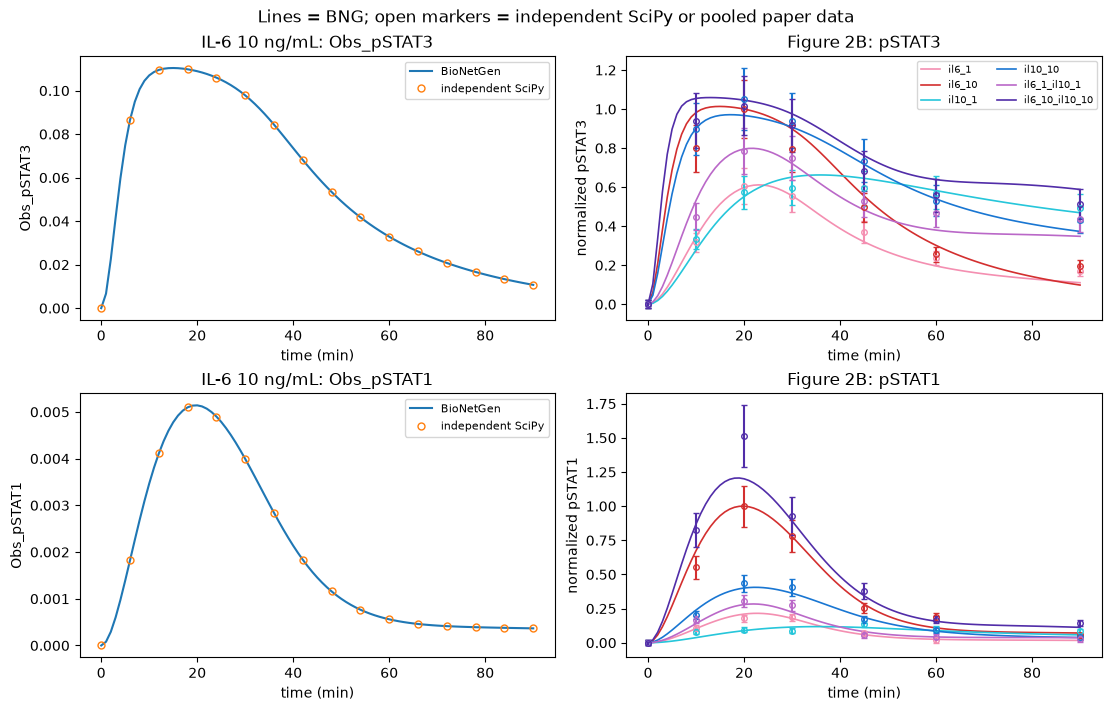

In [5]:
fig,ax=plt.subplots(2,2,figsize=(11,7),constrained_layout=True)
for a,o in zip(ax[:,0],obs):
 a.plot(bng.time,bng[o],lw=1.5,label='BioNetGen');a.plot(ind.time[::6],ind[o][::6],'o',mfc='none',ms=5,label='independent SciPy');a.set(xlabel='time (min)',ylabel=o,title=f'IL-6 10 ng/mL: {o}');a.legend(fontsize=8)
for a,(o,label) in zip(ax[:,1],[('Obs_pSTAT3','pSTAT3'),('Obs_pSTAT1','pSTAT1')]):
 for name in conds:
  d=reported[reported.condition==name];a.plot(tr[name].time,tr[name][o]/norm[o],color=COLORS[name],lw=1.2,label=name);a.errorbar(d.time,d[f'{label}_mean'],yerr=d[f'{label}_fit_SD'],fmt='o',mfc='none',color=COLORS[name],ms=4,capsize=2)
 a.set(xlabel='time (min)',ylabel=f'normalized {label}',title=f'Figure 2B: {label}')
ax[0,1].legend(fontsize=7,ncol=2);fig.suptitle('Lines = BNG; open markers = independent SciPy or pooled paper data');fig.savefig('verify_cheemalavagu2024.png',dpi=180);plt.show()

Acceptance tolerances: independent scaled error `<1e-4`; authors’ rounded trajectory relative error `<1e-3`; representative-ensemble pooled chi-square `<100` for 84 points. The last threshold is approximately one squared stated standard deviation per datum and does not claim a new refit.

In [6]:
assert np.max(err/scale)<1e-4
assert np.max(aerr[1:]/ascale[1:])<1e-3
assert chi2<100
print('All verification criteria passed.')

All verification criteria passed.
